# Tutorial: Programming with QoolQit

This notebook explains how QoolQit can be used to build quantum programs by employing the dimensionless Hamiltonian framework described in [Programming a neutral atom QPU](../get_started/rydberg_model.md).

QoolQit uses a **dimensionless reference frame** where all quantities are expressed relative to a reference interaction strength. This makes programs device-agnostic at definition time and portable across hardware configurations:

- Programs remain hardware-independent until compilation.
- Drive strengths are naturally expressed as multiples of interactions.
- The same program compiles to different devices without modification.

## The QoolQit Hamiltonian

Your system evolves under the following Hamiltonian:

$$
\tilde{H}(t) = \underbrace{\sum_{i<j} \tilde{J}_{ij}\,\hat{n}_i \hat{n}_j}_{\text{interactions}}
+ \underbrace{\sum_i \frac{\tilde{\Omega}(t)}{2} \left( \cos\phi(t)\,\hat{\sigma}^x_i - \sin\phi(t)\,\hat{\sigma}^y_i \right)}_{\text{global drive}}
- \underbrace{\sum_i \left( \tilde{\delta}(t) + \epsilon_i\,\tilde{\Delta}(t) \right) \hat{n}_i}_{\text{detuning}}
$$

where $\hat{n} = \frac{1}{2}(1 + \hat{\sigma}^z)$ is the Rydberg occupation operator.

| Symbol | Description | Range |
|--------|-------------|-------|
| $\tilde{J}_{ij}$ | Dimensionless coupling between qubits $i$ and $j$ | $(0, 1]$ |
| $\tilde{\Omega}(t)$ | Global Rabi frequency (drive amplitude) | $\geq 0$ |
| $\tilde{\delta}(t)$ | Global detuning | any |
| $\tilde{\Delta}(t)$ | Local detuning amplitude | $\leq 0$ |
| $\phi(t)$ | Drive phase | $[0, 2\pi)$ |
| $\epsilon_i$ | Local detuning weight for qubit $i$ | $[0, 1]$ |
| $\tilde{t}$ | Dimensionless time | $> 0$ | 

## Building Blocks of a Quantum Program

A QoolQit program is built from five core pieces:

1. **Register** — where qubits live (their geometry).
2. **Drive** — how you control the system over time (waveforms).
3. **QuantumProgram** — the pairing of *Register + Drive*.
4. **Compilation** — mapping the abstract program onto a specific device model.
5. **Execution** — running the compiled sequence and collecting results.

---
## 1. Register

A **register** defines the **positions** of qubits in your program. In neutral-atom / Rydberg analog models, geometry directly determines how strongly qubits interact.

> **Tip — use unit spacing**: the closest pair of qubits should be at distance **1**. This convention normalises interaction strengths and keeps drive parameters interpretable across different layouts.

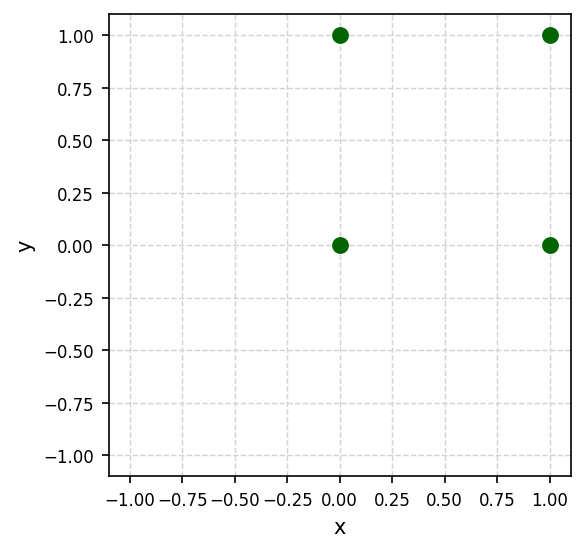

In [4]:
from qoolqit import Register

# Create a register from coordinates (dimensionless units)
register = Register.from_coordinates([
    (0, 0),
    (1, 0),
    (0.5, 0.866)
])

# Or use built-in graph patterns
from qoolqit import DataGraph

graph = DataGraph.square(m=2, n=2)
register = Register.from_graph(graph)  # 2x2 square lattice
register.draw()

For problem embedding, QoolQit also provides layout embedders that map graph structure onto qubit positions:

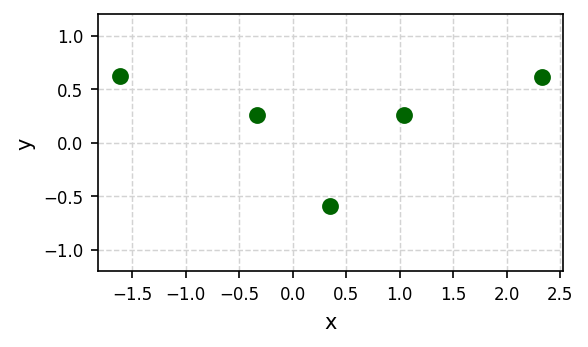

In [3]:
from qoolqit import DataGraph, Register, SpringLayoutEmbedder

graph = DataGraph.random_er(n=5, p=0.3, seed=3)
embedded_graph = SpringLayoutEmbedder().embed(graph)
register = Register.from_graph(embedded_graph)
register.draw()

> 📖 See [Registers](../fundamentals/registers.md) for all available register creation methods and options.
>
> 📖 See [Problem Embedding](../fundamentals/problem_embedding.md) for embedding data and problems into the Rydberg analog model.

---
## 2. Waveforms and Drives

A **drive** is the time-dependent control applied to the system, built from one or more **waveforms** — for example, amplitude $\tilde{\Omega}$ and detuning $\tilde{\delta}$ as functions of time $\tilde{t}$.

Waveform durations are dimensionless: $\tilde{t}$ measures duration relative to an interaction timescale. In an interacting many-body system, this gives $\tilde t$ a natural physical interpretation in terms of the buildup and propagation of correlations.

| Regime | Condition | Physical meaning |
|--------|-----------|------------------|
| Short time | $\tilde{t} \ll 1$ | Too short for interactions to strongly reshape the state |
| Long time | $\tilde{t} \sim n$ | Correlations may have propagated across a distance of order $n$ lattice spacings |

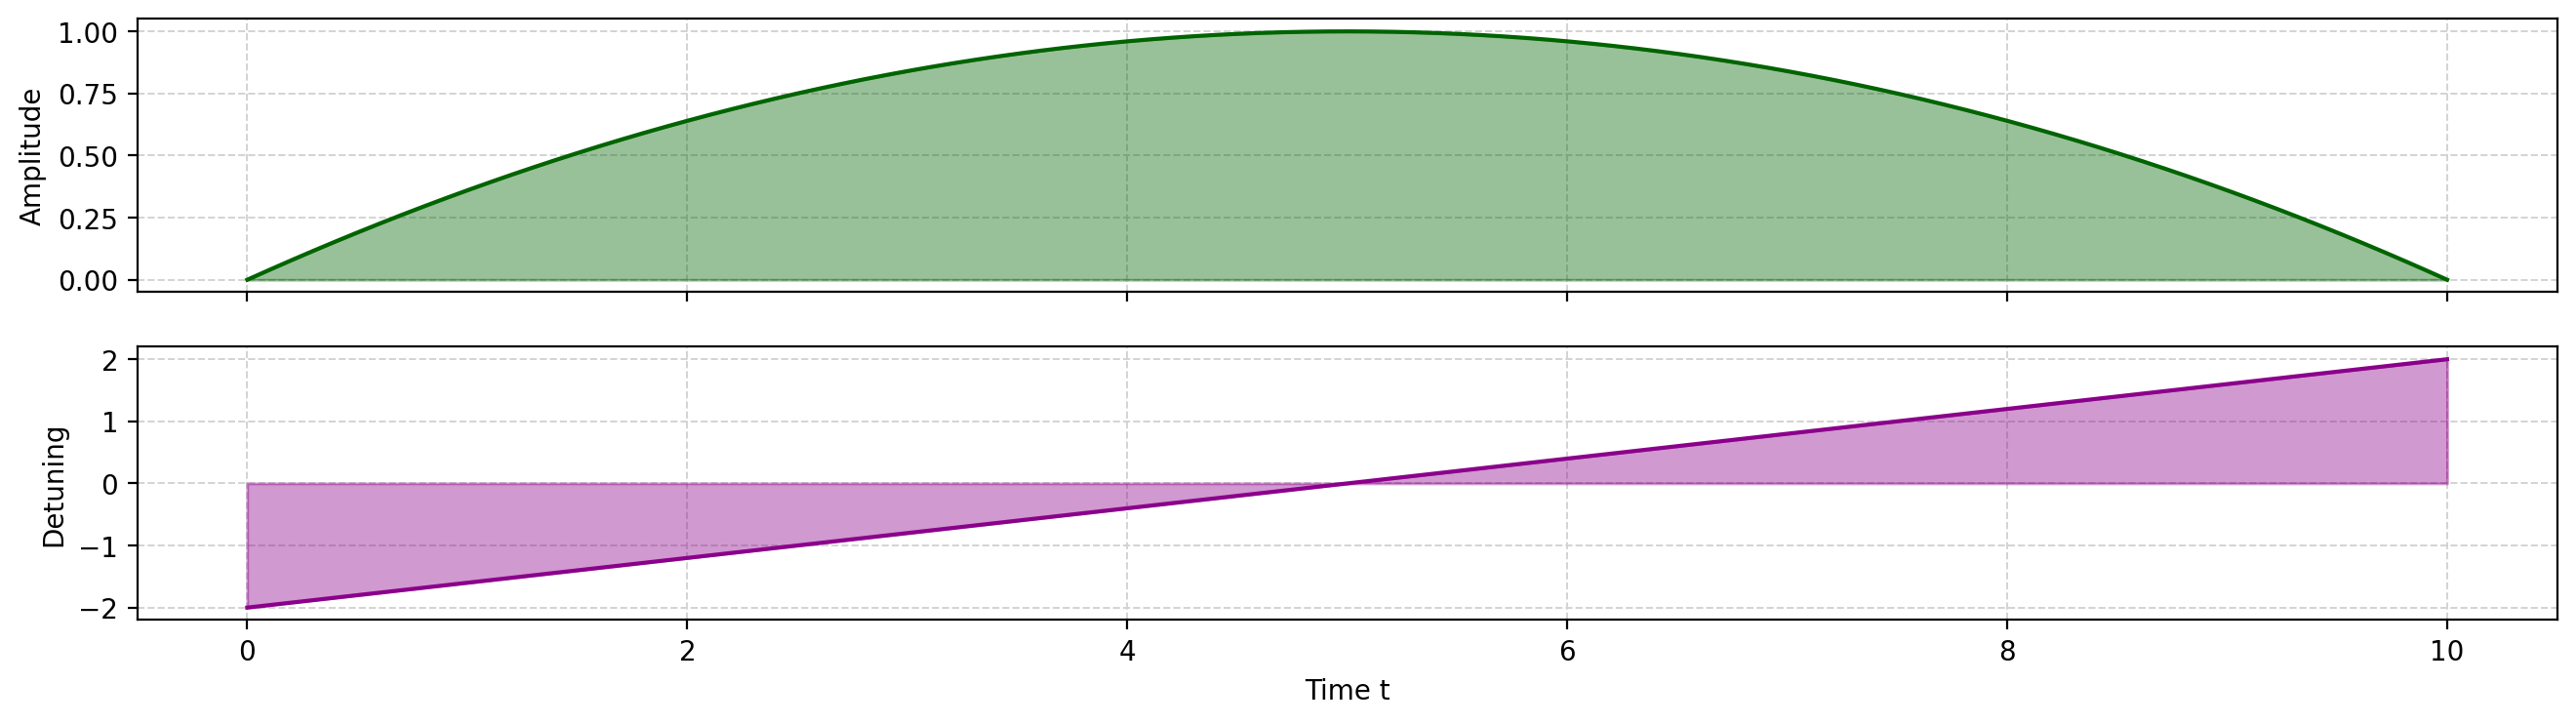

In [16]:
from qoolqit import Drive
from qoolqit.waveforms import Constant, Interpolated, Ramp

# Interpolated waveform: smooth curve through specified values
omega_wf = Interpolated(duration=10, values=[0, 1, 0])

# Constant waveform
delta_wf = Constant(duration=10, value=-2)

# Ramp waveform
delta_wf = Ramp(duration=10, initial_value=-2, final_value=2)

# Combine into a Drive
drive = Drive(
    amplitude=omega_wf,
    detuning=delta_wf
)

drive.draw()

> 📖 See [Waveforms](../fundamentals/waveforms.md) for all waveform types and options.
>
> 📖 See [Drive Hamiltonian](../fundamentals/drives.md) for details on combining waveforms into drives.

---
## 3. QuantumProgram

A `QuantumProgram` pairs a **register** (layout and interactions) with a **drive** (time-dependent controls). The initial state is always $|0\rangle^{\otimes N}$, so every program describes how the drive and interactions evolve this fixed initial state.

In [17]:
from qoolqit import QuantumProgram

program = QuantumProgram(
    register=register,
    drive=drive
)

> 📖 See [Quantum Programs](../fundamentals/programs.md) for more details.

---
## 4. Compilation

Compilation translates your abstract program into something a given device (or emulator) can actually run, applying device-specific constraints such as maximum duration, amplitude and detuning bounds, discretization rules, and other hardware limits.

In [18]:
from qoolqit import AnalogDevice

device = AnalogDevice()
program.compile_to(device)

---
## 5. Execution

Once compiled, run the sequence and retrieve results. The three stages map cleanly onto three concepts:

- **Program** — what you *want* to run (abstract physics).
- **Sequence** — what you *will* run (device-compatible instructions).
- **Result** — what you *observed* (samples, probabilities, observables, etc.).

In [19]:
from qoolqit.execution import LocalEmulator

emulator = LocalEmulator()
results = emulator.run(program)

> 📖 See [Devices](../fundamentals/devices.md) for available devices and their specifications.
>
> 📖 See [Execution](./fundamentals/execution.md) for running programs and handling different result types.

---
## Example: Rydberg Blockade Demonstration

The **blockade regime** occurs when interactions prevent nearby atoms from being simultaneously excited. In the dimensionless framework this is straightforward to set up:

- Place two qubits at unit distance $\Rightarrow \tilde{J} = 1$.
- Blockade condition: $\tilde{\Omega} \ll 1$ (drive is weak compared to interactions).

We will compare two programs:

| Case | $\tilde{\Omega}$ | Regime | Expected behaviour |
|------|-----------------|--------|--------------------|
| Blockade | $0.3$ | $\tilde{\Omega} \ll \tilde{J}$ | Double excitation $|11\rangle$ suppressed |
| Non-blockade | $2.0$ | $\tilde{\Omega} \gg \tilde{J}$ | Qubits behave more independently; $|11\rangle$ accessible |

In [20]:
import numpy as np

from qoolqit import Drive, QuantumProgram, Register
from qoolqit.devices import AnalogDevice
from qoolqit.execution import BitStrings, EmulationConfig, LocalEmulator
from qoolqit.waveforms import Constant

# Two qubits at unit distance => maximum interaction J = 1
register = Register.from_coordinates([(0, 0), (1, 0)])

duration = 10

# Blockade regime: Omega << J => double excitation is suppressed
drive_blockade = Drive(
    amplitude=Constant(duration, 0.3),  # Omega = 0.3 << 1
    detuning=Constant(duration, 0.0)
)

# Non-blockade regime: Omega >> J => drive dominates, both atoms can be excited
drive_no_blockade = Drive(
    amplitude=Constant(duration, 2.0),  # Omega = 2.0 >> 1
    detuning=Constant(duration, 0.0)
)

In [21]:
# Build and compile programs
program_blockade = QuantumProgram(register, drive_blockade)
program_no_blockade = QuantumProgram(register, drive_no_blockade)

device = AnalogDevice()
program_blockade.compile_to(device)
program_no_blockade.compile_to(device)

In [22]:
# Configure emulation: sample bitstrings at 81 evaluation times
eval_times = np.linspace(0.0, 1.0, 81)
bitstrings = BitStrings(evaluation_times=list(eval_times), num_shots=1000)
configuration = EmulationConfig(observables=[bitstrings])

emulator = LocalEmulator(emulation_config=configuration)

results_blockade = emulator.run(program_blockade)
results_no_blockade = emulator.run(program_no_blockade)

                        and in `EmulationConfig`, ignoring the former


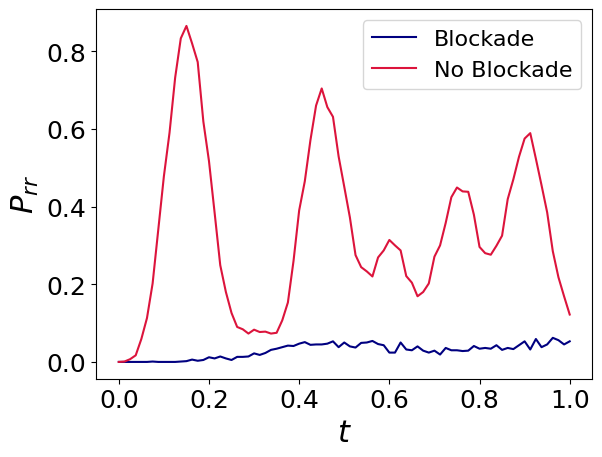

In [23]:
import matplotlib.pyplot as plt

times=results_blockade[0].get_result_times(bitstrings)
occupation=[results_blockade[0].get_result(bitstrings.tag,time=t)["11"]/1000
             for k,t in enumerate(times)]
plt.plot(times,occupation,
         label="Blockade",
         color="navy")
times=results_no_blockade[0].get_result_times(bitstrings)
occupation=[results_no_blockade[0].get_result(bitstrings.tag,time=t)["11"]/1000
             for k,t in enumerate(times)]
plt.plot(times,occupation,
         label="No Blockade",
         color="crimson")
plt.xlabel(r"$t$",fontsize=22)
plt.ylabel(r"$P_{rr}$",fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16)

### What to expect

- **Blockade case** ($\tilde{\Omega} = 0.3$): the strong interaction heavily penalises the $|11\rangle$ state. You should observe a suppressed probability of both qubits being excited simultaneously.
- **Non-blockade case** ($\tilde{\Omega} = 2.0$): the drive dominates and interactions are comparatively weak, so the two qubits behave more independently and $|11\rangle$ becomes much more accessible.

> 📖 See [Solving a Basic QUBO Problem](../tutorials/solving_a_qubo.ipynb) for another application example.